In [2]:
import numpy as np
import matplotlib.pyplot as plt
import UBOP as ub

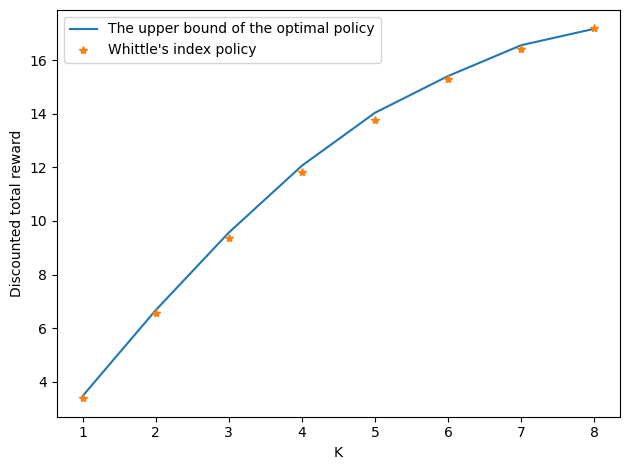

In [30]:
# 1) Fig.13 论文参数

beta = 0.8
N = 8
p01 = np.array([0.2, 0.5, 0.8, 0.1, 0.6, 0.2, 0.3, 0.8], dtype=float)
p11 = np.array([0.4, 0.1, 0.3, 0.6, 0.2, 0.8, 0.7, 0.6], dtype=float)
omega0 = p01 / (p01 + (1.0 - p11))  
K_list = list(range(1, N+1))

episodes = 10000
horizon  = 400
eps      = 1e-2
grid     = ub.BeliefGrid(grid_n=401)



# 2) 构建 Whittle 指数表

def build_whittle_table(beta, p01, p11, grid):
    table = np.zeros((len(p01), grid.grid_n))
    for i in range(len(p01)):
        for gi, w in enumerate(grid.grid):
            table[i, gi] = ub.whittle_index_numeric(beta, p01[i], p11[i], w, grid)
    return table

def w_interp(row, grid, omega):
    return grid.interp(row, np.clip(omega, 0.0, 1.0))

W_table = build_whittle_table(beta, p01, p11, grid)



# 3) 适配 compute_upper_bound_eps 返回值

def extract_m_G(res):
    # 若是 dict
    if isinstance(res, dict):
        # 优先用标准命名
        for mk in ["m_prime", "m_mid", "m"]:
            if mk in res: m = res[mk]; break
        for gk in ["G_upper", "G", "upper"]:
            if gk in res: G = res[gk]; break
        return m, G
    # 若是 tuple / list
    if isinstance(res, (tuple, list)):
        # 直接取前两个（大多数 UBOP 实现都是 m, G, stop_interval, ...）
        return res[0], res[1]
    raise ValueError("compute_upper_bound_eps 返回格式无法识别")



# 4) 硬约束 Whittle 策略仿真

def simulate_whittle(beta, K, p01, p11, omega_init, grid, w_table, episodes=episodes, horizon=horizon, seed=12345):
    rng = np.random.default_rng(seed)
    disc = np.power(beta, np.arange(horizon))
    total = 0.0
    for _ in range(episodes):
        omega = omega_init.copy()
        G = 0.0
        for t in range(horizon):
            # 计算每条臂的 Whittle 指数并选出最大 K 条
            W = np.array([w_interp(w_table[i], grid, omega[i]) for i in range(len(p01))])
            idx = np.argpartition(W, -K)[-K:]
            active = np.zeros(len(p01), dtype=bool); active[idx] = True
            # 当前奖励 = 激活臂的 ω 之和
            G += disc[t] * float(omega[active].sum())
            # 动作后更新
            # 激活臂：根据观测跳转
            ids = np.where(active)[0]
            if ids.size:
                rnd = rng.random(ids.size)
                good = rnd < omega[ids]
                omega[ids[good]]  = p11[ids[good]]
                omega[ids[~good]] = p01[ids[~good]]
            # 未激活臂：未观测推进
            idle = np.where(~active)[0]
            if idle.size:
                omega[idle] = omega[idle]*p11[idle] + (1-omega[idle])*p01[idle]
        total += G
    return total / episodes



# 5) 扫 K 画图

upper, index = [], []
for K in K_list:
    res = ub.compute_upper_bound_eps(beta, K, p01, p11, omega0, eps, grid)
    m_mid, G_up = extract_m_G(res)
    upper.append(G_up)
    index.append(simulate_whittle(beta, K, p01, p11, omega0, grid, W_table))

plt.figure()
plt.plot(K_list, upper, '-', label="The upper bound of the optimal policy")
plt.plot(K_list, index, '*', label="Whittle's index policy")
plt.xlabel("K"); plt.ylabel("Discounted total reward")
plt.legend(); plt.tight_layout()
plt.savefig("Fig13_reproduction_graph_2.png")


In [31]:
beta = 0.8
K = 2
p01 = np.array([0.2, 0.5, 0.8, 0.1, 0.6, 0.2, 0.3, 0.8], dtype=float)
p11 = np.array([0.4, 0.1, 0.3, 0.6, 0.2, 0.8, 0.7, 0.6], dtype=float)

#  初始信念：若无先验，取稳态 ω_o
omega0 = p01 / (p01 + (1 - p11))
grid = ub.BeliefGrid(grid_n=401)
m_prime, G_upper, stop_interval, gray_ranges = ub.compute_upper_bound_eps(beta, K, p01, p11, omega0, eps, grid)
print("m' ≈", m_prime, "   区间=", stop_interval)
print("上界 G ≈", G_upper)

m' ≈ 0.6000001192092894    区间= (0.6000001192092894, 0.6239619493484498)
上界 G ≈ 6.670233255638362


In [32]:
beta = 0.8
K = 3
p01 = np.array([0.2, 0.5, 0.8, 0.1, 0.6, 0.2, 0.3, 0.8], dtype=float)
p11 = np.array([0.4, 0.1, 0.3, 0.6, 0.2, 0.8, 0.7, 0.6], dtype=float)

#  初始信念：若无先验，取稳态 ω_o
omega0 = p01 / (p01 + (1 - p11))
grid = ub.BeliefGrid(grid_n=401)
m_prime, G_upper, stop_interval, gray_ranges = ub.compute_upper_bound_eps(beta, K, p01, p11, omega0, eps, grid)
print("m' ≈", m_prime, "   区间=", stop_interval)
print("上界 G ≈", G_upper)

m' ≈ 0.5226161718368529    区间= (0.5226161718368529, 0.5426830530166626)
上界 G ≈ 9.568060210698118
